In [1]:
# application id: CTPF6RC7C51

In [2]:
# !uv add matplotlib
# !uv add torch
# !uv add torchvision

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [4]:
transform = transforms.ToTensor()
train_datasets = datasets.MNIST(
    root = ".data/",
    train = True,
    download = True,
    transform = transform
)

test_datasets = datasets.MNIST(
    root = "./data",
    train = False,
    download = True,
    transform = transform
)

In [5]:
train_loader = DataLoader(
    dataset = train_datasets,
    batch_size = 64,
    shuffle = True
)
test_loader = DataLoader(
    dataset = test_datasets,
    batch_size = 64,
    shuffle = False
)

In [6]:
class SimpleNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )


    def forward(self, X):

        return self.model(X)

In [7]:
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [8]:
for epoch in range(10):

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch: {epoch+1} loss: {loss.item()}")

epoch: 1 loss: 0.08957052230834961
epoch: 2 loss: 0.0023742401972413063
epoch: 3 loss: 0.01487621758133173
epoch: 4 loss: 0.017464106902480125
epoch: 5 loss: 0.10882700234651566
epoch: 6 loss: 0.0022783551830798388
epoch: 7 loss: 0.11509843915700912
epoch: 8 loss: 0.000282908120425418
epoch: 9 loss: 0.3592661917209625
epoch: 10 loss: 0.010770738124847412


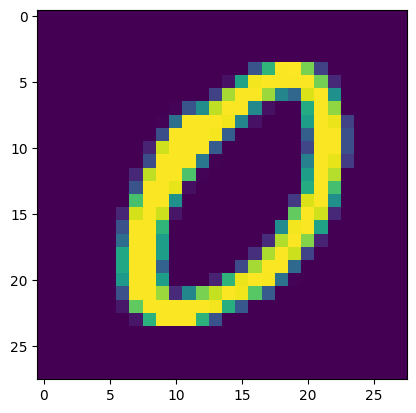

In [9]:
images, labels = next(iter(train_loader))
plt.imshow(images[1].squeeze())
plt.show()